# Integrating the GLIF3 step exactly

**Companion to `report.pdf`.** That report states the result; this notebook
computes it. Every number and figure below comes from `_study.py` and
`_figures.py`, which the report also reads, so the two cannot disagree.
Notation follows the thesis (Galván Fraile, 2025), Sections 1.2--1.3.

---

## The problem in one paragraph

The V1 model advances each GLIF3 neuron with a step of $\delta t = 1$ ms. The
synaptic and after-spike currents obey linear equations, and the original code
already used their *exact* one-step solutions. Only the membrane update was
approximate: it used an **Euler** step, which
freezes the total synaptic current at its start-of-step value (a *zero-order
hold* on the current),

$$V_j[t+\delta t] = \alpha V_j[t] + (1-\alpha) R_m\, I_j[t] - S_j[t]\,\Delta V ,$$

which is exact only if $I_j$ is constant across the step. With a fastest
synaptic basis of $\tau_1 = 0.99$ ms against $\delta t = 1$ ms, it is not: the
alpha-shaped current rises and falls by an order of magnitude *inside* one
step. The same step also applies the reset and the after-spike current of a
spike one step late (the $-S_j[t]\,\Delta V$ term acts at the end of the step).
Both approximations matter, and at ~10 Hz the event timing is the larger one
(Section 3). We replace that step with the exact propagator of the coupled
$(C^{\mathrm{syn}}, I^{\mathrm{syn}}, I^{s}, V)$ system.

| symbol | code | meaning |
|---|---|---|
| $V_j[t]$ | `v` | membrane potential of neuron $j$, in units of $\Delta V = V_{th} - E_L$ |
| $C^{\mathrm{syn}}_{j,r}[t]$ | `psc_rise` | rise variable of receptor basis $r$ |
| $I^{\mathrm{syn}}_{j,r}[t]$ | `psc` | postsynaptic current of receptor basis $r$ |
| $I^{s}_j[t]$ | `asc` | after-spike current, $s \in \{1,2\}$ |
| $S_j[t]$ | `prev_z` | spike indicator, $S_j[t] \in \{0,1\}$ |
| $\alpha = e^{-\delta t/\tau_m}$ | `decay` | membrane decay factor |
| $\alpha_r = e^{-\delta t/\tau_r}$ | `syn_decay` | synaptic decay factor |
| $\beta_s = e^{-k^{s}\delta t}$ | `asc_decay` | ASC decay factor |
| $\mathcal{A}_{j,r}$ | `psc_factor` | how $I^{\mathrm{syn}}_{j,r}$ drives $V_j$ across the step |
| $\mathcal{B}_{j,r}$ | `psc_rise_factor` | how $C^{\mathrm{syn}}_{j,r}$ drives $V_j$ across the step |
| $\mathcal{D}^{s}_j$ | `asc_factor` | how $I^{s}_j$ drives $V_j$ across the step |
| $\mathcal{R}_j$ | `reset_coeff` | the whole effect of a spike on $V_j$ |

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath("../.."))
sys.path.insert(0, os.path.abspath("."))

import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import expm

import _simulation as S
import _figures as F
import _study
from v1_model_utils.glif_propagators import membrane_coefficients

%matplotlib inline
F.use_style()

p, coeffs = _study.parameters()
inputs, spikes = _study.drive(p)
N = p["tau_m"].size

print(f"{N} GLIF3 cell types,  dt = {S.DT} ms")
print(f"synaptic bases   tau_r (ms): {np.round(S.TAU_SYN, 2)}")
print(f"membrane         tau_m (ms): min {p['tau_m'].min():.1f}  "
      f"median {np.median(p['tau_m']):.1f}  max {p['tau_m'].max():.1f}")
print(f"after-spike      tau_s (ms): {np.round(1 / np.unique(p['k']), 1)}")

201 GLIF3 cell types,  dt = 1.0 ms
synaptic bases   tau_r (ms): [0.99 1.88 3.63 5.65]
membrane         tau_m (ms): min 5.5  median 14.3  max 51.8
after-spike      tau_s (ms): [333.3 100.   33.3  10.    3.3]


## 1. Why the Euler step fails here

Two facts make that hold untenable at $\delta t = 1$ ms:

* the fastest receptor basis peaks *at* $t = \tau_1 \approx \delta t$, i.e. within
  the first step after the presynaptic spike;
* a newly arrived spike sets $C^{\mathrm{syn}}_{j,r}$, not $I^{\mathrm{syn}}_{j,r}$ --- the latter is
  still zero at the grid point, so Euler integrates the entire first
  millisecond of every postsynaptic current as **zero**.

### The current updates were already exact

The update $I^{\mathrm{syn}}_{j,r}[t+\delta t] = \alpha_r\bigl(I^{\mathrm{syn}}_{j,r}[t]
+ \delta t\, C^{\mathrm{syn}}_{j,r}[t]\bigr)$ looks as if it holds $C^{\mathrm{syn}}$
constant over the step, but it does not. With no arriving spike,
$C^{\mathrm{syn}}(t+u) = e^{-u/\tau_r} C^{\mathrm{syn}}(t)$, and

$$I^{\mathrm{syn}}(t+u) = e^{-u/\tau_r}\bigl(I^{\mathrm{syn}}(t) + u\,C^{\mathrm{syn}}(t)\bigr)$$

satisfies $\dot I^{\mathrm{syn}} = -I^{\mathrm{syn}}/\tau_r + C^{\mathrm{syn}}(t+u)$
exactly. It is exact because the two variables share $\tau_r$. Once that
common decay is factored out, $e^{u/\tau_r} C^{\mathrm{syn}}(t+u) = C^{\mathrm{syn}}(t)$
really is constant, and $\delta t$ is its exact integral. For example, with
$\tau_r = \delta t = 1$ ms, $I^{\mathrm{syn}} = 0$ and $C^{\mathrm{syn}} = 1$,
the code gives $e^{-1} \approx 0.37$, the exact value. A genuine forward-Euler
step would give $1$. The after-spike currents decay by $e^{-k^s \delta t}$,
which is exact too. The approximation is entirely in how $V$ uses these currents.

### When an arriving spike takes effect

The new input is added to $C^{\mathrm{syn}}$ undecayed, and $I^{\mathrm{syn}}$ uses
the old $C^{\mathrm{syn}}$. That is the exact solution for a spike arriving at the
**end** of the step. The jump has no time left to decay, and $I^{\mathrm{syn}}$,
being continuous, has not seen it yet. With this convention the delays come out
exactly: a spike at $t_n$ is read by a synapse with delay $d\,\delta t$ after
$d-1$ steps, and lands at the end of that step, at $t_n + d\,\delta t$. Placing
it at the start would make every synapse act one step early, and the 1 ms
delays would become instantaneous. The neuron's own spike is the opposite case:
it happens at $t_n$, so its reset and ASC increment act at the start of the
next step.

| event | occurs at | enters the step |
|---|---|---|
| own spike: reset and $\delta I^s$ | $t_n$ | at the start of $[t_n, t_{n+1})$ |
| arrival with delay $d\,\delta t$ | $t_n + d\,\delta t$ | at the end of $[t_{n+d-1}, t_{n+d})$ |

### Event conventions against the fitted model

Teeter *et al.* (2018) fitted the GLIF3 parameters. Their fitting code
(`ASGLM.py` and `GLM.create_basis_IPSP` in the
[AllenSDK](https://github.com/AllenInstitute/AllenSDK/tree/master/allensdk/internal/model))
regresses the voltage on basis currents $e^{-k^s(t - t_{\mathrm{sp}})}$ that start at
spike **initiation**, and drops only the samples inside the refractory window.
So the fitted ASC is $\delta I^s e^{-k^s(t - t_{\mathrm{sp}})}$ from the spike on, and
the membrane restarts at $V_{\mathrm{reset}} = E_L$ when the window ends.

| | fitted model | exact step (soft reset, training) | exact step (hard reset) |
|---|---|---|---|
| ASC jump | $\delta I^s$ at the spike, then decays | same | same |
| membrane | not modelled in the window, $E_L$ after it | $-\Delta V$ at the spike, then integrates freely | $V_{\mathrm{reset}}$ at the spike, held until $t_n + \lceil t_{\mathrm{ref}}\rceil - 1$ |
| next spike | after $t_{\mathrm{sp}} + t_{\mathrm{ref}}$ | $t_n + \lceil t_{\mathrm{ref}}\rceil$ | same |

The true crossing lies in $(t_{n-1}, t_n]$, so $t_n + \lceil t_{\mathrm{ref}}\rceil$ is the
first grid point that can follow the end of the window. The soft reset keeps the
overshoot and whatever input arrives during refractoriness, which is what we
want for training. It is also a departure from the fit: the after-spike currents
keep driving the membrane during refractoriness, while the fitted model does not
simulate it there and the hard reset holds it. Only with no input, no overshoot
and no after-spike current does it return to $E_L$ as the hard reset does. NEST's `glif_psc` resets at the same grid point, but it follows the Allen
simulator: it adds $\delta I^s$ undecayed at the *end* of the window, which does not
match the fitted current, and it counts $t_{\mathrm{ref}}$ from the detection time.

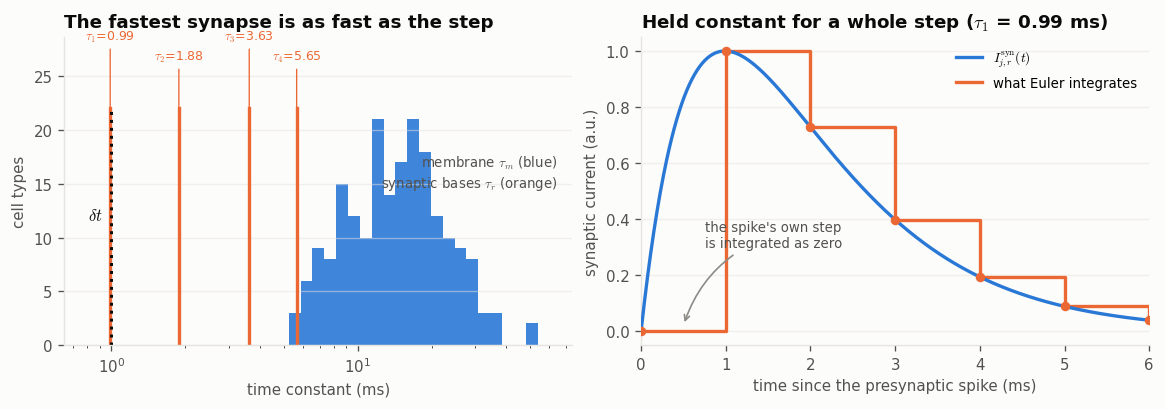

In [2]:
F.timescales(p["tau_m"], S.TAU_SYN, S.DT)
plt.show()

## 2. The exact step

Between spikes the neuron is a linear time-invariant system
$\dot{\mathbf{y}}_j = \mathbf{M}_j \mathbf{y}_j$, so the one-step transition is
the matrix exponential $e^{\mathbf{M}_j \delta t}$ --- the propagator construction of
Rotter & Diesmann (1999), which NEST uses for `iaf_psc_alpha`. Integrating the
membrane equation exactly gives a convolution rather than a product,

$$V_j(t+\delta t) = e^{-\delta t/\tau_m}V_j(t)
  + \frac{1}{C_m}\int_0^{\delta t} e^{-(\delta t-u)/\tau_m} I_j(t+u)\,\mathrm{d}u ,$$

and since every source is a known exponential or alpha function on the step,
each integral is a constant:

$$V_j[t+\delta t] = \alpha V_j[t]
  + \sum_{r}\bigl(\mathcal{A}_{j,r}I^{\mathrm{syn}}_{j,r}[t] + \mathcal{B}_{j,r}C^{\mathrm{syn}}_{j,r}[t]\bigr)
  + \sum_{s}\mathcal{D}^{s}_{j} I^{s}_j[t] + \mathcal{R}_j S_j[t] .$$

A spike does *two* things to its own step, and they get one constant each:

$$\underbrace{\mathcal{R}_j = -\alpha\,\Delta V}_{\text{the reset}},
  \qquad
  \underbrace{\mathcal{S}_j = \sum_s \mathcal{D}^{s}_j\,\delta I^{s}}_{\text{the ASC it injects}} .$$

Both multiply the same $S_j[t]$, so the forward pass *could* fold them into one
constant --- but they must not be, because `detach_reset` and `detach_asc_reset`
gate them separately in the backward pass. See section 5.

So the step needs **no new state** ($C^{\mathrm{syn}}$ was already there). Setting
$\mathcal{A}_{j,r} = \mathcal{D}^{s}_j = (1-\alpha)R_m$, $\mathcal{B}_{j,r} = 0$,
$\mathcal{R}_j = -\Delta V$, $\mathcal{S}_j = 0$ recovers the old scheme exactly
--- the integrator is a *choice of constants*, not a branch in the code.

See `report.pdf` §3 for the closed forms. They need care near
$\tau_m = \tau_r$, which is a real case here --- the slowest basis, 5.65 ms,
sits inside the membrane range 5.5--51.8 ms, and the closest cell type reaches
$|x| = 1.8\times10^{-3}$ where $x = (1/\tau_m - 1/\tau_r)\,\delta t$. The
coefficient $\mathcal{B}$ is the delicate one: its factor
$(e^{x}(x-1)+1)/x^{2}$ builds a quantity of size $x^{2}/2$ out of two of size
1, losing eight digits at $x = 10^{-4}$, so it is evaluated through
$1 + (x-1)\varphi_2(x)$ and a Taylor series instead.

### Verification

An independent check: a general-purpose matrix exponential must reproduce the
hand-derived coefficients.

In [3]:
identity = _study.propagator_identity(p, coeffs)
# The last digits depend on the LAPACK build, so assert an order, not a value.
print(f"max |scipy.linalg.expm  -  closed form|  =  {identity['worst']:.1e}"
      "   (machine precision)")
assert identity["worst"] < 1e-12

b = S.TAU_SYN.size
row = expm(S.system_matrix(p["tau_m"][0], p["g"][0], S.TAU_SYN, p["k"][0]) * S.DT)[-1]
print(f"\nneuron 0, from expm:   A = {np.round(row[b:2*b], 6)}")
print(f"        closed form:   A = {np.round(coeffs['exact']['A'][0], 6)}")

max |scipy.linalg.expm  -  closed form|  =  1.1e-16   (machine precision)

neuron 0, from expm:   A = [0.01064  0.013188 0.01491  0.015655]
        closed form:   A = [0.01064  0.013188 0.01491  0.015655]


## 3. Accuracy

Measuring the exact scheme against a reference built *from* the exact
propagator would be circular. The ground truth is therefore built from the
**old** method: the Euler step is first-order accurate, so sub-stepping it at
$\delta t/M$ converges, and a Richardson extrapolation $2f(2M) - f(M)$ cancels the
leading error term, giving a reference good to $\sim 10^{-7}$ that never
touches the closed form under test. The reference takes only Euler's
*integration* from the old method: it applies the spike events at the start of
each step, as the exact scheme does, so it measures only the integration error.

The plot below is the proof: the sub-stepped Euler step walks towards the propagator
as $1/M$ and never overtakes it.

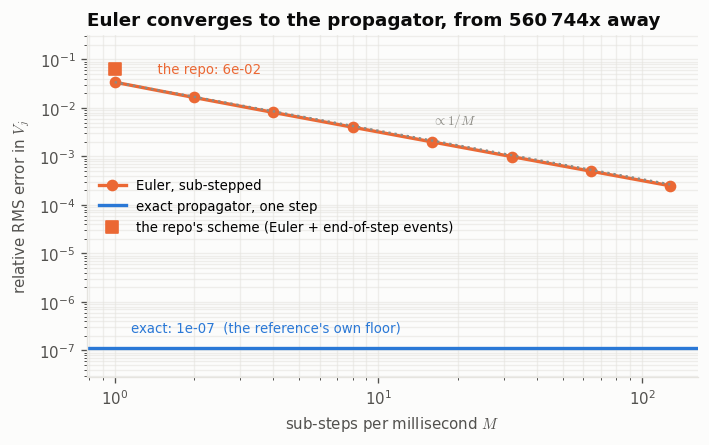

    M    rel. RMS error in V_j
    1                3.396e-02
    2                1.641e-02
    4                8.068e-03
    8                4.002e-03
   16                1.993e-03
   32                9.945e-04
   64                4.968e-04
  128                2.483e-04
exact                1.137e-07   (bounded by the reference)

The sub-stepped curve also fixes the event timing, so its M = 1 point (3.40e-02)
is already better than the scheme the repo ran (6.37e-02).


In [4]:
conv = _study.convergence(p, coeffs, inputs, spikes)
F.convergence(conv["substeps"], conv["errors"], conv["exact"], conv["legacy"])
plt.show()

print(f"{'M':>5} {'rel. RMS error in V_j':>24}")
for m, e in zip(conv["substeps"], conv["errors"]):
    print(f"{m:>5} {e:>24.3e}")
print(f"{'exact':>5} {conv['exact']:>24.3e}   (bounded by the reference)")
print(f"\nThe sub-stepped curve also fixes the event timing, so its M = 1 point "
      f"({conv['errors'][0]:.2e})\nis already better than the scheme the repo ran "
      f"({conv['legacy']:.2e}).")

### Error in the two regimes, at both precisions

Two drives, because they stress different parts of the step: **subthreshold**
(no postsynaptic spikes, so the error is purely the membrane integration of
$I^{\mathrm{syn}}$) and **spiking** (adds the reset and the ASCs, whose event timing the
exact scheme also fixes).

Three storage choices. float64 isolates the *method*. Then `float16` for the
four recurrent state blocks. Then `float16` for the propagator **constants**
too --- which is what the production kernel actually does, because under a
mixed-precision policy the layer's `compute_dtype` is `float16` and every
constant is stored in it. Arithmetic stays in `float32` throughout.

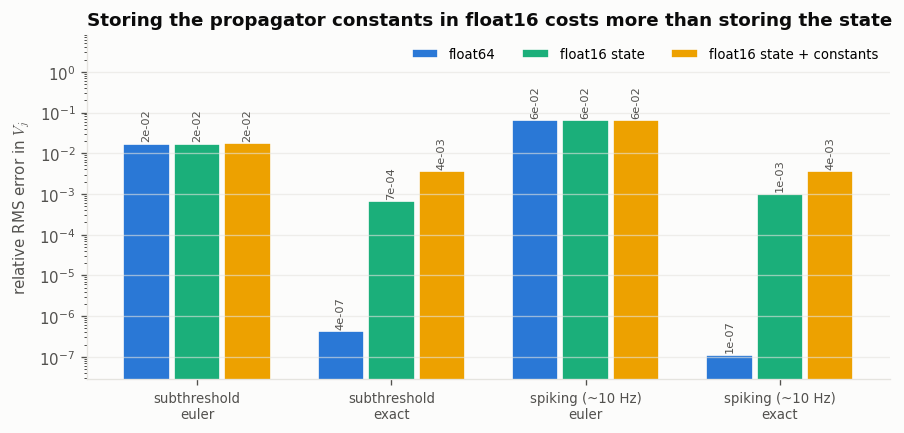

regime            scheme       float64   fp16 state  + constants
----------------------------------------------------------------
subthreshold      euler      1.688e-02    1.684e-02    1.755e-02
subthreshold      exact      4.234e-07    6.603e-04    3.633e-03
spiking (~10 Hz)  euler      6.374e-02    6.391e-02    6.427e-02
spiking (~10 Hz)  exact      1.137e-07    9.964e-04    3.631e-03

subthreshold       improvement:  float64     39,871x   production float16     5x
spiking (~10 Hz)   improvement:  float64    560,744x   production float16    18x

narrowing the constants alone costs 3.6x on top of narrowing the state.

The float64 figure is a lower bound: the exact scheme sits at the reference's
own accuracy floor, so what is measured there is the reference, not the scheme.


In [5]:
rows = _study.errors(p, coeffs, inputs, spikes)
F.error_bars(rows)
plt.show()

hdr = (f"{'regime':<18}{'scheme':<8}{'float64':>12}{'fp16 state':>13}"
       f"{'+ constants':>13}")
print(hdr); print("-" * len(hdr))
for r in rows:
    print(f"{r['case']:<18}{r['scheme']:<8}{r['fp64']:>12.3e}"
          f"{r['fp16_state']:>13.3e}{r['fp16']:>13.3e}")
print()
for case in ("subthreshold", "spiking (~10 Hz)"):
    euler, exact = [r for r in rows if r["case"] == case]
    print(f"{case:<18} improvement:  float64 {euler['fp64']/exact['fp64']:>10,.0f}x"
          f"   production float16 {euler['fp16']/exact['fp16']:>5.0f}x")
spk = [r for r in rows if r["case"] == "spiking (~10 Hz)" and r["scheme"] == "exact"][0]
print(f"\nnarrowing the constants alone costs "
      f"{spk['fp16']/spk['fp16_state']:.1f}x on top of narrowing the state.")
print("\nThe float64 figure is a lower bound: the exact scheme sits at the "
      "reference's\nown accuracy floor, so what is measured there is the "
      "reference, not the scheme.")

Read the float64 column first. Euler's error is $6.4\times10^{-2}$ of
$\Delta V$ --- over **6% of the distance from rest to threshold**, per neuron,
all the time. That is a systematically wrong trajectory, not a rounding
artefact.

Now read across, and the expected answer reverses twice. Under Euler, moving
from float64 to `float16` changes *nothing*: the discretisation error is some
forty times larger than anything the number format contributes. Precision was
never the *integrator's* bottleneck. But once the integrator is exact,
precision becomes the floor --- and it is not the state that dominates it.
Narrowing the **constants** costs another $3.6\times$ on top of narrowing the
state, which is why the production figure is $3.6\times10^{-3}$ rather than
the $1.0\times10^{-3}$ the state alone would suggest. Section 6 returns to
this: the constants are the cheapest thing here to widen.

### Which of Euler's two approximations causes the error?

The Euler step holds the synaptic current over the step *and* applies the
spike events (the reset and the ASC increment) at the end of it. The two live
in disjoint constants: the current in $A$, $B$, $D$, the events in
`reset_coeff`, `asc_spike_factor` and `asc_jump`. So each one can be fixed on
its own.

In [6]:
dec = _study.decomposition(p, coeffs, inputs, spikes)
labels = dict(euler="both (Euler)", events_only="event timing only",
              current_only="current hold only", exact="neither (exact)")
print(f"{'remaining approximation':<26}{'subthreshold':>14}{'spiking':>12}")
for key, label in labels.items():
    print(f"{label:<26}{dec['subthreshold'][key]:>14.2e}{dec['spiking'][key]:>12.2e}")

remaining approximation     subthreshold     spiking
both (Euler)                    1.69e-02    6.37e-02
event timing only               4.23e-07    4.85e-02
current hold only               1.69e-02    2.59e-02
neither (exact)                 4.23e-07    1.14e-07


Without spikes, the current hold is the entire error. At the imposed ~10 Hz
output rate, the **event timing is the larger share**, and neither fix alone
gets within two orders of magnitude of the exact step. The split depends on
the rate: the event error scales with the number of spikes, the hold error
with the synaptic drive.

### One presynaptic spike, one neuron

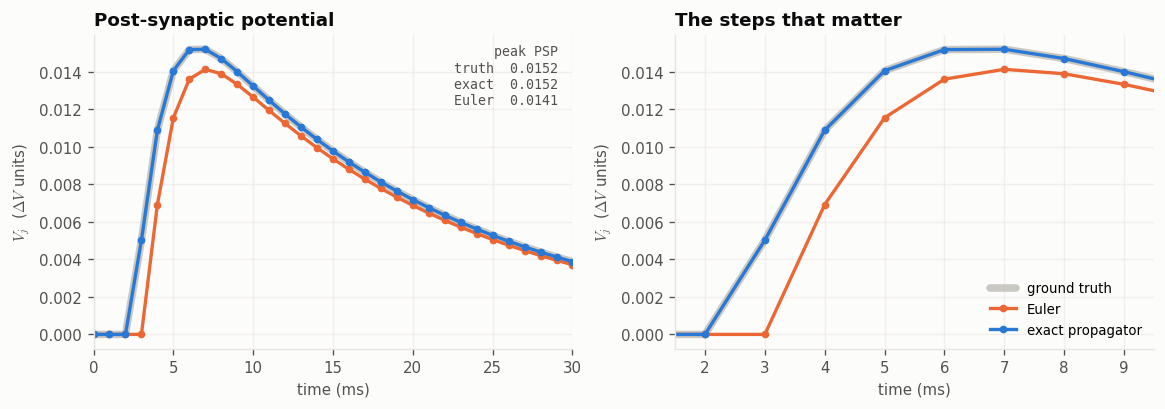

peak PSP underestimated by Euler: 7.0%


In [7]:
psp = _study.psp(p, coeffs)
F.psp(psp["ms"], psp["truth"], psp["traces"], psp["peaks"])
plt.show()
print(f"peak PSP underestimated by Euler: {psp['underestimate']*100:.1f}%")

## 4. Does it change the spikes?

Voltage error matters only insofar as it moves spikes. Here the loop is closed:
neurons integrate, cross threshold, reset, adapt and block during their
refractory period, driven by a fixed Poisson input. The ground truth is again
the **old** method, sub-stepped in float64 (here at $\delta t/4096$), so it
favours neither scheme. Richardson extrapolation cannot be used here: once
neurons spike on their own, runs at $M$ and $2M$ can diverge by a whole spike,
and a raster cannot be extrapolated. Plain sub-stepped Euler is first order, so
this reference's own voltage error is about $6.4\times10^{-2}/4096 \approx
1.6\times10^{-5}$ of $\Delta V$ --- small next to Euler's error, but not next to
the exact scheme's. The exact scheme's float64 agreement is therefore a lower
bound, and the cell prints how it moves against an 8x coarser reference.

The metric is deliberately strict --- the fraction of ground-truth spikes
reproduced in *exactly* the same millisecond. A closed loop amplifies any
voltage discrepancy into a different spike time, after which the trajectories
separate.

ground truth: 1723 spikes, mean rate 10.7 Hz
scheme  precision         spikes at the right ms   rate error
-------------------------------------------------------------
euler   float64                             7.1%        3.54%
euler   float16                             5.2%        3.66%
euler   mixed                               7.2%        3.54%
exact   float64                            99.9%        0.00%
exact   float16                            61.9%        0.06%
exact   mixed                              95.3%        0.00%

exact, float16: 657 spikes missed, 59% of them exactly 1 ms off, so 84% of all spikes land within +-1 ms
exact, float64, against a reference with M = 512: 99.7%  (reference-limited)


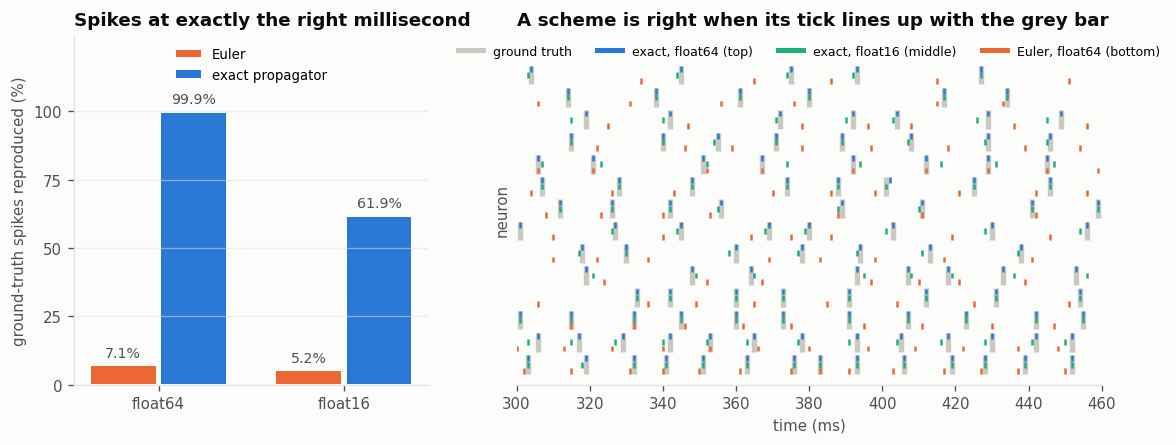

In [8]:
closed = _study.closed_loop(p, coeffs)
print(f"ground truth: {closed['n_spikes']} spikes, mean rate {closed['rate']:.1f} Hz")

hdr = f"{'scheme':<8}{'precision':<16}{'spikes at the right ms':>24}{'rate error':>13}"
print(hdr); print("-" * len(hdr))
for r in closed["rows"]:
    print(f"{r['scheme']:<8}{r['precision']:<16}{r['match']*100:>23.1f}%"
          f"{r['rate_err']*100:>12.2f}%")
print(f"\nexact, float16: {closed['half_missed']} spikes missed, "
      f"{closed['half_one_off']*100:.0f}% of them exactly 1 ms off, so "
      f"{closed['half_within_one']*100:.0f}% of all spikes land within +-1 ms")
print(f"exact, float64, against a reference with M = {_study.CLOSED_SUBSTEPS // 8}: "
      f"{closed['coarse_match']*100:.1f}%  (reference-limited)")

F.spike_fidelity(closed["rows"], closed["reference"], closed["by_scheme"],
                 slice(300, 460))
plt.show()

The rasters make the point better than the numbers: the exact propagator's
float64 raster (top) *is* the ground truth's raster. Euler's (bottom) is a
plausible-looking spike train of roughly the right rate that is, spike for
spike, a different one. The exact propagator in the production `float16`
configuration (middle) sits in between: most of its spikes land in the right
millisecond, and more than half of those that do not are off by exactly one.

Note what this does **not** claim. Euler is stable and its firing rates are
only ~3.5% off, so a network trained under it is a perfectly self-consistent
dynamical system. It is simply not the GLIF3 system its parameters describe.
Any quantity that depends on spike timing --- synchrony, phase, latency,
temporal codes, or the surrogate gradients that flow through the threshold
crossing --- was being computed for the wrong model.

## 5. Are the gradients right?

The model is trained by BPTT, so the propagator is only as useful as its
Jacobian. Differentiating the step gives, for upstream gradients
$\bar V, \bar I^{s}, \bar C, \bar I$ on the four outputs,

$$\frac{\partial\mathcal{L}}{\partial V_j[t]} = \alpha\,\bar V,
  \qquad
  \frac{\partial\mathcal{L}}{\partial I^{\mathrm{syn}}_{j,r}[t]}
    = \alpha_r\,\bar I_r + \mathcal{A}_{j,r}\,\bar V,
  \qquad
  \frac{\partial\mathcal{L}}{\partial C^{\mathrm{syn}}_{j,r}[t]}
    = \alpha_r\,\bar C_r + \delta t\,\alpha_r\,\bar I_r
      + \mathcal{B}_{j,r}\,\bar V,$$

$$\frac{\partial\mathcal{L}}{\partial I^{s}_j[t]}
    = \beta_s\,\bar I^{s} + \mathcal{D}^{s}_j\,\bar V,
  \qquad
  \frac{\partial\mathcal{L}}{\partial S_j[t]}
    = \underbrace{\mathcal{R}_j\,\bar V}_{\text{gated by }\texttt{detach_reset}}
    + \underbrace{\mathcal{S}_j\,\bar V
        + \textstyle\sum_s \widetilde{\delta I^{s}}\,\bar I^{s}}_{\text{gated by }\texttt{detach_asc_reset}} .$$

Every new coefficient appears in the backward pass exactly where it appears in
the forward one, so the added cost is the same handful of multiply-adds.

The last equation is why $\mathcal{R}_j$ and $\mathcal{S}_j$ are kept apart:
**each detach flag gates its own term**. Folding them into one constant would
make `detach_reset` silently cut part of the ASC gradient as well, and
$\mathcal{S}_j$ reaches 28% of $|\mathcal{R}_j|$ for some cell types.

The TensorFlow path is plain ops, so autodiff handles it; the CUDA path carries
a hand-written backward kernel. Both were checked against central finite
differences of the forward step (`verify_gradients.py`). Two inputs are excluded
because a finite difference there measures a step function rather than the
transition: the emitted spikes (a Heaviside with a surrogate gradient) and the
delayed spike buffer (the event-driven recurrent kernel consumes a spike as a
binary event). Both are pre-existing model choices, independent of the
integrator.

In [9]:
grad = _study.gradients()
if grad is None:
    print("run verify_gradients.py to generate gradient_check.json")
else:
    blocks = ("prev_z", "v", "asc", "psc_rise", "psc")
    hdr = f"{'backend / scheme':<22}" + "".join(f"{n:>12}" for n in blocks)
    print(hdr); print("-" * len(hdr))
    for key, b in grad["blocks"].items():
        print(f"{key:<22}" + "".join(f"{b[n]['rel_err']:>12.2e}" for n in blocks))
    worst_z = max(b["prev_z"]["rel_err"] for b in grad["blocks"].values())
    print("\nrelative discrepancy between the analytic gradient and a central "
          "finite difference")
    print(f"worst over every backend, scheme and state block: {grad['overall']:.2e}"
          "  (the float32 difference-quotient noise floor)")
    print(f"the spike gradient, exactly linear and so free of truncation error: "
          f"{worst_z:.1e}")

backend / scheme            prev_z           v         asc    psc_rise         psc
----------------------------------------------------------------------------------
tensorflow/euler          7.41e-05    7.83e-03    1.92e-02    4.45e-03    7.75e-03
tensorflow/exact          8.05e-05    4.78e-03    1.08e-02    3.57e-03    4.97e-03
cuda/euler                7.41e-05    7.83e-03    1.92e-02    4.45e-03    7.75e-03
cuda/exact                8.05e-05    4.78e-03    1.08e-02    3.57e-03    4.97e-03

relative discrepancy between the analytic gradient and a central finite difference
worst over every backend, scheme and state block: 1.92e-02  (the float32 difference-quotient noise floor)
the spike gradient, exactly linear and so free of truncation error: 8.1e-05


## 6. Now that the method error is gone, what does `float16` cost?

With the integrator exact, `float16` *storage* is the floor. Five things are
stored: the four recurrent state blocks and the propagator constants. They are
not equally expensive to widen --- per neuron per sample,
$I^{\mathrm{syn}}$ and $C^{\mathrm{syn}}$ are four words each, $I^{s}$ is two
and $V_j$ is one, while the constants are shared across the batch *and* the
sequence and so cost nothing per sample at all.

stored as float16                 rel. RMS error   B/neuron/sample
------------------------------------------------------------------
v, psc, rise, asc                      9.964e-04                22
v, psc, rise, asc, constants           3.631e-03                22  (constants are shared, so they add nothing here)
psc, rise                              3.404e-05                28
v, asc                                 9.932e-04                38
asc                                    7.778e-04                40
v                                      6.596e-04                42
nothing                                4.959e-07                44

for scale, Euler with everything in float16: 6.427e-02


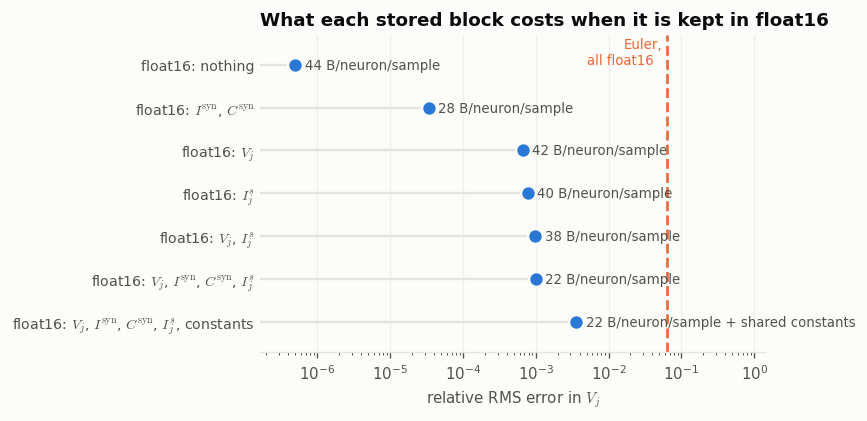

In [10]:
prec = _study.precision(p, coeffs, inputs, spikes)
hdr = (f"{'stored as float16':<32}{'rel. RMS error':>16}"
       f"{'B/neuron/sample':>18}")
print(hdr); print("-" * len(hdr))
for a in sorted(prec["rows"], key=lambda a: a["bytes"]):
    note = "  (constants are shared, so they add nothing here)" if a.get(
        "coeffs_narrow") else ""
    print(f"{a['half']:<32}{a['err']:>16.3e}{a['bytes']:>18d}{note}")
print(f"\nfor scale, Euler with everything in float16: {prec['euler_fp16']:.3e}")

F.precision_ablation(prec["rows"], prec["euler_fp16"])
plt.show()

Two results here, pointing the same way.

Among the **state** blocks the cost is counter-intuitive. $I^{\mathrm{syn}}$
and $C^{\mathrm{syn}}$ --- eight of the eleven words per neuron --- cost almost
nothing in `float16`, while $I^{s}$, two words, costs more than both together.
The after-spike currents carry large amplitudes and decay over hundreds of
milliseconds, so their `float16` ulp is coarse and the error accumulates for a
long time before it decays. Keeping only $V_j$ and $I^{s}_j$ in `float32`
recovers most of the float64 accuracy for three extra words per neuron.

The **constants** are the better bargain, and were the easier thing to miss.
Narrowing them costs more than every state block put together, and they are
the largest single term in the production number. But they do not scale with
batch or sequence length: 25 words per neuron, shared, so widening all of them
to `float32` is a fixed ~12 MB at 230,924 neurons. The obstacle is plumbing,
not memory --- the fused operator takes one dtype for every tensor, so mixed
state and constant widths need a second type parameter on the op.

**Both are follow-ups, not part of this change.** The integrator fix is
unconditional; these are deliberate trades this notebook quantifies so they can
be made on evidence. On the numbers above, widen the constants first.

## 7. Cost

Equation for $V_j[t+\delta t]$ replaces one scaled sum by a weighted sum: $R$ extra
fused multiply-adds per neuron per step, and per-basis coefficient arrays where
there was one scalar. The coefficients are shared across the batch and stay in
L2, and $C^{\mathrm{syn}}_{j,r}$ was *already* read by the kernel. **No new state, so no
extra VRAM on the BPTT tape** --- which is what actually constrains this model.

In [11]:
bench = _study.benchmark()
if bench is None:
    print("run benchmark_kernels.py to generate benchmark_results.json")
else:
    hdr = (f"{'neurons':>9}{'batch':>7}{'dtype':>7}{'Euler fwd':>11}{'exact fwd':>11}"
           f"{'Euler bwd':>11}{'exact bwd':>11}{'per step':>11}")
    print(hdr); print("-" * len(hdr))
    for r in bench["rows"]:
        print(f"{r['n']:>9}{r['batch']:>7}{r['dtype']:>7}{r['legacy_fwd']:>10.1f}us"
              f"{r['new_fwd']:>10.1f}us{r['legacy_bwd']:>10.1f}us"
              f"{r['new_bwd']:>10.1f}us{r['ratio']:>10.2f}x")
    print(f"\nfloat16 (what training uses): {bench['fp16_mean']:.2f}x the kernel "
          f"time, range {bench['fp16_min']:.2f}-{bench['fp16_max']:.2f}x")
    print("recurrent state per neuron per timestep: unchanged")

  neurons  batch  dtype  Euler fwd  exact fwd  Euler bwd  exact bwd   per step
------------------------------------------------------------------------------
    51978      8   fp16      15.3us      16.6us      20.0us      20.9us      1.06x
    51978      8   fp32      26.4us      33.1us      32.7us      36.7us      1.18x
    51978     32   fp16      50.5us      55.7us      66.2us      71.2us      1.09x
    51978     32   fp32     116.9us     135.0us     141.7us     150.8us      1.11x
   230924      8   fp16      57.4us      64.1us      73.8us      81.2us      1.11x
   230924      8   fp32     136.8us     152.2us     156.2us     165.6us      1.08x
   230924     32   fp16     293.4us     315.4us     345.5us     379.5us      1.09x
   230924     32   fp32     580.2us     647.1us     658.9us     690.8us      1.08x

float16 (what training uses): 1.09x the kernel time, range 1.06-1.11x
recurrent state per neuron per timestep: unchanged


So the fused state kernel costs about **9% more** in `float16`. That is the
cost of that one kernel, not of a training step: the state transition is one of
several kernels per timestep and the recurrent CSR products dominate. The
end-to-end training step has not been measured.

The overhead is not irreducible either. The inner loop reads four separate
$[N \times R]$ constant arrays at the same index; interleaving them into one
array of four values per $(j, r)$ would turn four strided loads into a single
`float4` fetch. A worthwhile follow-up, not a prerequisite.

## 8. Two defects the rewrite exposed

Reworking the setup code turned up two bugs that predate the propagator and
have nothing to do with it. Both are fixed.

**The ASC decay went through `float16`.** $\beta_s = e^{-k^{s}\delta t}$ was
not computed from $k^{s}$ directly: the rate was cast to the compute dtype,
pushed through an inverse sigmoid, stored, and pushed back through a sigmoid on
read --- a parameterisation left over from when $k$ was to be trained. Under
mixed precision that round trip happens in `float16` and returns $k^{s}$ with a
relative error of $2\times10^{-3}$. The resulting error in $\beta_s$ looks
negligible at $3.6\times10^{-5}$, but it is an error in a *decay rate*: over
three ASC time constants it compounds to **0.6%** of the after-spike current's
amplitude, and the slowest ASC has $\tau = 333$ ms. It is now evaluated in
float64 and cast once.

**A neuron-aligned constant was not following the layout.** The model can
renumber neurons into a spatially local (Morton) order at runtime while keeping
checkpoints canonical, and `_translate_neuron_layout` permutes the
neuron-aligned arrays when it does. It worked from a hand-written list of
attribute names, and `t_ref_steps` was not on it --- so under a non-identity
layout **every neuron got somebody else's refractory period**, drawn from a
range of 2 to 10 steps. The read is live in both backends.

The second is the more instructive failure. A list of names that has to be kept
in step with a set of attributes will eventually fall out of step; the
edge-aligned translation beside it does not have the problem, because it
discovers its targets. The per-neuron constants are now built by a helper that
binds and registers in one call, so the registry cannot disagree with what
exists, and a test asserts that every constant the step reads is in it and
survives a permutation round trip.

## 9. Using it

```python
model = models.create_model(..., integration_scheme="exact")   # default
model = models.create_model(..., integration_scheme="euler")     # reproduce old runs
```

and `--integration_scheme={exact,euler}` for `multi_training.py`,
`osi_dsi_estimator.py` and `parallel_training_testing.py`.

**Checkpoint compatibility.** The coefficients are derived constants,
deliberately kept out of the trackable graph, so checkpoints written before
this change still restore and are interchangeable between the two schemes
(`tests/test_cuda_glif_state.py` asserts both). What is *not* interchangeable
is the science: a network whose weights were trained under Euler was fitted
to a different dynamical system, so expect firing rates to shift. Use `euler` to
reproduce an old run, and retrain for new ones.

**What is still on the grid.** Spikes are emitted and delivered only at
millisecond boundaries. Morrison et al. (2007) show how to carry continuous
spike times through the same propagator formalism, which would remove the
remaining sub-millisecond quantisation --- a larger change, orthogonal to this
one, and the natural next target now that the subthreshold integration is
exact.

### References

* Rotter, S. & Diesmann, M. (1999). Exact digital simulation of time-invariant
  linear systems with applications to neuronal modeling. *Biol. Cybern.* 81,
  381--402.
* Morrison, A., Straube, S., Plesser, H. E. & Diesmann, M. (2007). Exact
  subthreshold integration with continuous spike times in discrete-time neural
  network simulations. *Neural Comput.* 19, 47--79.
* Mihalaş, Ş. & Niebur, E. (2009). A generalized linear integrate-and-fire
  neural model produces diverse spiking behaviors. *Neural Comput.* 21,
  704--718.
* Teeter, C. *et al.* (2018). Generalized leaky integrate-and-fire models
  classify multiple neuron types. *Nat. Commun.* 9, 709.
* Galván Fraile, J. (2025). *Neocortical Dynamics and Computational
  Mechanisms*. PhD thesis, Universitat de les Illes Balears. (Notation:
  Sections 1.2--1.3.)